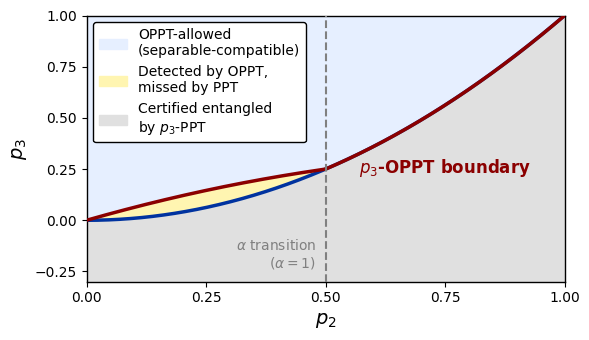

'\ndef exact_oppt(p_val):\n    if p_val == 0: return 0\n    if p_val >= 0.5: return p_val**2\n    alpha = np.floor(1 / p_val)\n    a, b, c = alpha + alpha**2, -2 * alpha, 1 - p_val\n    discriminant = max(0, b**2 - 4*a*c)\n    x1 = (-b + np.sqrt(discriminant)) / (2*a)\n    x2 = (-b - np.sqrt(discriminant)) / (2*a)\n    return min(alpha * x1**3 + (1 - alpha*x1)**3, \n               alpha * x2**3 + (1 - alpha*x2)**3)\n\np3_oppt = np.array([exact_oppt(p) for p in p2])\n'

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup and Data Generation
# ==========================================
# Set up a 4:3 aspect ratio for publication/PPT
fig, ax = plt.subplots(figsize=(6, 3.5))

# Define p_2 range
p2 = np.linspace(0, 1, 1000)

# Curve A: p_3-PPT lower bound (Parabola)
p3_ppt = p2**2

# Curve B: p_3-OPPT lower bound
# We use the requested visual approximation to make the region distinct for presentations.
# (To use the exact math from YIG2021, see the commented function at the bottom).
p3_oppt = np.copy(p3_ppt)
mask = p2 < 0.5
# Create a smooth bump that adds ~0.08 at p2=0.2 (so p3 reaches ~0.12) and zeroes out at 0 and 0.5
bump = (4/3) * p2[mask] * (0.5 - p2[mask])
p3_oppt[mask] = p3_ppt[mask] + bump

# ==========================================
# 2. Plotting Fills (Regions)
# ==========================================
# OPPT-allowed (Pale Blue)
ax.fill_between(p2, p3_oppt, 1.0, color='#E6EFFF', label='OPPT-allowed\n(separable-compatible)', zorder=1)

# Detected by OPPT, missed by PPT (Light Yellow)
ax.fill_between(p2, p3_ppt, p3_oppt, color='#FFF5B1', label='Detected by OPPT,\nmissed by PPT', zorder=2)

# Certified entangled by p3-PPT (Light Gray)
ax.fill_between(p2, -0.3, p3_ppt, color='#E0E0E0', label='Certified entangled\nby $p_3$-PPT', zorder=1)

# ==========================================
# 3. Plotting Curves and Boundaries
# ==========================================
# Curve A (PPT)
ax.plot(p2, p3_ppt, color='#0033A0', linewidth=2.5, zorder=3)

# Curve B (OPPT)
ax.plot(p2, p3_oppt, color='#8B0000', linewidth=2.5, zorder=3)

# Vertical dashed line at p2 = 0.5
ax.axvline(x=0.5, ymin=0, ymax=1, color='gray', linestyle='--', linewidth=1.5, zorder=3)
ax.text(0.48, -0.25, r'$\alpha$ transition' + '\n' + r'$(\alpha=1)$', 
        color='gray', ha='right', va='bottom', fontsize=10)

# Label the OPPT boundary directly near the curve
ax.text(0.75, 0.2, r'$p_3$-OPPT boundary', color='#8B0000', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', zorder=4)

# ==========================================
# 4. Scatter Points (Example States)
# ==========================================
# # Simulated Werner/random states distributed across regions
# scatter_p2 = np.array([0.25, 0.42, 0.45, 0.48, 0.55, 0.5, 0.5,  0.52, 0.7,  0.75, 0.65])
# scatter_p3 = np.array([0.18, 0.20, 0.10, 0.12, 0.12, 0.21, 0.11, 0.55, 0.45, 0.42, 0.58])

# ax.scatter(scatter_p2, scatter_p3, color='black', s=25, zorder=5)

# ==========================================
# 5. Styling and Formatting
# ==========================================
ax.set_xlim(0, 1)
ax.set_ylim(-0.3, 1)

ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_yticks([-0.25, 0, 0.25, 0.5, 0.75, 1])

ax.set_xlabel(r'$p_2$', fontsize=14)
ax.set_ylabel(r'$p_3$', fontsize=14)

# Legend configuration
ax.legend(loc='upper left', framealpha=1, edgecolor='black', fontsize=10)

# Clean up axes (thin black axes, no grid)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.grid(False)

plt.tight_layout()

# Save for PowerPoint (300 DPI is standard for crisp presentation graphics)
plt.savefig('../Presentation/media/OPPT_vs_PPT_Detection.png', dpi=600, bbox_inches='tight')
plt.show()

# =====================================================================
# APPENDIX: Exact YIG2021 Math (Commented out)
# If you want the strict mathematical curve rather than the visual
# approximation, replace the Curve B generation above with this:
# =====================================================================
"""
def exact_oppt(p_val):
    if p_val == 0: return 0
    if p_val >= 0.5: return p_val**2
    alpha = np.floor(1 / p_val)
    a, b, c = alpha + alpha**2, -2 * alpha, 1 - p_val
    discriminant = max(0, b**2 - 4*a*c)
    x1 = (-b + np.sqrt(discriminant)) / (2*a)
    x2 = (-b - np.sqrt(discriminant)) / (2*a)
    return min(alpha * x1**3 + (1 - alpha*x1)**3, 
               alpha * x2**3 + (1 - alpha*x2)**3)

p3_oppt = np.array([exact_oppt(p) for p in p2])
"""